<a href="https://colab.research.google.com/github/RaulR1603/actividad2/blob/main/Actividad_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad individual: Transformers y Modelos de Lenguaje Grande (LLM)

**Asignatura:** Sistemas Cognitivos Artificiales

En esta actividad se utilizará el dataset Banking77 para realizar una clasificación
multiclase de consultas bancarias mediante DistilRoBERTa. Posteriormente se analizarán
los errores de clasificación y se utilizará un modelo LLM para generar explicaciones
sobre algunas de las predicciones incorrectas.

In [ ]:
# Comprobamos la GPU disponible en Google Colab
!nvidia-smi

Mon Oct  5 20:36:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Preparación del entorno

En esta sección se instalan e importan las librerías necesarias para el desarrollo
de la actividad. También se establece una semilla aleatoria para favorecer la
reproducibilidad de los experimentos.

In [ ]:
# Instalación de dependencias
# Se fija datasets==3.6.0 por compatibilidad con Banking77.
!pip install -q "datasets==3.6.0" transformers accelerate evaluate wordcloud

In [ ]:
import datasets
import fsspec

print("datasets:", datasets.__version__)
print("fsspec:", fsspec.__version__)

datasets: 3.6.0
fsspec: 2025.3.0


In [ ]:
# Librerías para manipulación y análisis de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import random
import torch
import nltk

# Librerías para NLP y visualización
from wordcloud import WordCloud

# Hugging Face
from datasets import load_dataset

# Semilla para reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
GPU disponible: True
GPU: Tesla T4


## 2. Carga del conjunto de datos

Se utiliza el dataset Banking77, compuesto por consultas bancarias breves en inglés
clasificadas en 77 intenciones diferentes. El dataset proporciona conjuntos
separados para entrenamiento y prueba.

In [ ]:
# Cargamos el dataset Banking77 desde Hugging Face
# trust_remote_code=True permite ejecutar el script necesario para cargar el dataset.
dataset = load_dataset(
    "PolyAI/banking77",
    trust_remote_code=True
)

dataset

README.md:   0%|          | 0.00/9.78k [00:00<?, ?B/s]

banking77.py:   0%|          | 0.00/7.17k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/5.89k [00:00<?, ?B/s]

/root/.cache/huggingface/modules/datasets_modules/datasets/PolyAI--banking77/17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9/banking77.py:25: SyntaxWarning: invalid escape sequence '\~'
  author      = {I{\~{n}}igo Casanueva and Tadas Temcinas and Daniela Gerz and Matthew Henderson and Ivan Vulic},


Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

In [ ]:
# Observamos un ejemplo del conjunto de entrenamiento
dataset["train"][0]

{'text': 'I am still waiting on my card?', 'label': 11}

In [ ]:
# Obtenemos los nombres de las 77 clases
class_names = dataset["train"].features["label"].names

print("Número de clases:", len(class_names))
print("\nPrimeras 10 clases:")

for i, clase in enumerate(class_names[:10]):
    print(i, "-", clase)

Número de clases: 77

Primeras 10 clases:
0 - activate_my_card
1 - age_limit
2 - apple_pay_or_google_pay
3 - atm_support
4 - automatic_top_up
5 - balance_not_updated_after_bank_transfer
6 - balance_not_updated_after_cheque_or_cash_deposit
7 - beneficiary_not_allowed
8 - cancel_transfer
9 - card_about_to_expire


In [ ]:
# Convertimos el conjunto de entrenamiento a un DataFrame
df_train = dataset["train"].to_pandas()

# Añadimos el nombre de la clase para facilitar la interpretación
df_train["category"] = df_train["label"].apply(lambda x: class_names[x])

df_train.head(10)

,text,label,category
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival
5,When did you send me my new card?,11,card_arrival
6,Do you have info about the card on delivery?,11,card_arrival
7,What do I do if I still have not received my n...,11,card_arrival
8,Does the package with my card have tracking?,11,card_arrival
9,I ordered my card but it still isn't here,11,card_arrival


## 3. Análisis exploratorio de datos (EDA)

Antes de entrenar el modelo se realiza un análisis exploratorio del conjunto de
entrenamiento para conocer las principales características de las consultas,
su longitud, vocabulario y distribución entre las diferentes categorías.

Este análisis permitirá identificar características del dataset que posteriormente
puedan ayudar a interpretar el comportamiento y los errores del modelo de clasificación.

### 3.1 Longitud de las consultas

Se analiza la longitud de cada consulta utilizando dos medidas: número de caracteres
y número de palabras. Esto permite conocer el tamaño habitual de los textos que
posteriormente serán procesados por el modelo.

In [ ]:
# Calculamos la longitud de cada consulta
df_train["num_caracteres"] = df_train["text"].str.len()
df_train["num_palabras"] = df_train["text"].str.split().str.len()

# Visualizamos los primeros registros
df_train[
    ["text", "num_caracteres", "num_palabras", "category"]
].head(10)

,text,num_caracteres,num_palabras,category
0,I am still waiting on my card?,30,7,card_arrival
1,What can I do if my card still hasn't arrived ...,60,13,card_arrival
2,I have been waiting over a week. Is the card s...,58,12,card_arrival
3,Can I track my card while it is in the process...,59,13,card_arrival
4,"How do I know if I will get my card, or if it ...",54,15,card_arrival
5,When did you send me my new card?,33,8,card_arrival
6,Do you have info about the card on delivery?,44,9,card_arrival
7,What do I do if I still have not received my n...,54,13,card_arrival
8,Does the package with my card have tracking?,44,8,card_arrival
9,I ordered my card but it still isn't here,41,9,card_arrival


In [ ]:
# Estadísticas descriptivas de la longitud de las consultas
estadisticas_longitud = df_train[
    ["num_caracteres", "num_palabras"]
].describe()

estadisticas_longitud

,num_caracteres,num_palabras
count,10003.000000,10003.000000
mean,59.473758,11.949415
std,40.867901,7.891577
min,13.000000,2.000000
25%,36.000000,7.000000
50%,47.000000,10.000000
75%,64.000000,13.000000
max,433.000000,79.000000


**Interpretación**
Las consultas del conjunto de entrenamiento son en general, texto breves. La longitud media es de aproximadamente 59 caracteres y 12 palabras, mientras que la mediana es de 47 caracteres y 10 palabras. El 75% de las consultas tiene 13 palabras o menos.

Sin embargo, se observa una diferencia importante entre los valores habituales y los maximos, ya que existen consultas de hasta 433 caracteres y 79 palabras. Esque indica la presencia de algunas conusltas considerablemente mas largas que la mayoria.

Este resultado será relevante duante la tikenizacion del model Transformer, ya que permitirá seleccionar posteriormente una longitud maxima de secuencia que represente adecuadamente las consultas sin utilizar un tamaño innecesariamente grande.

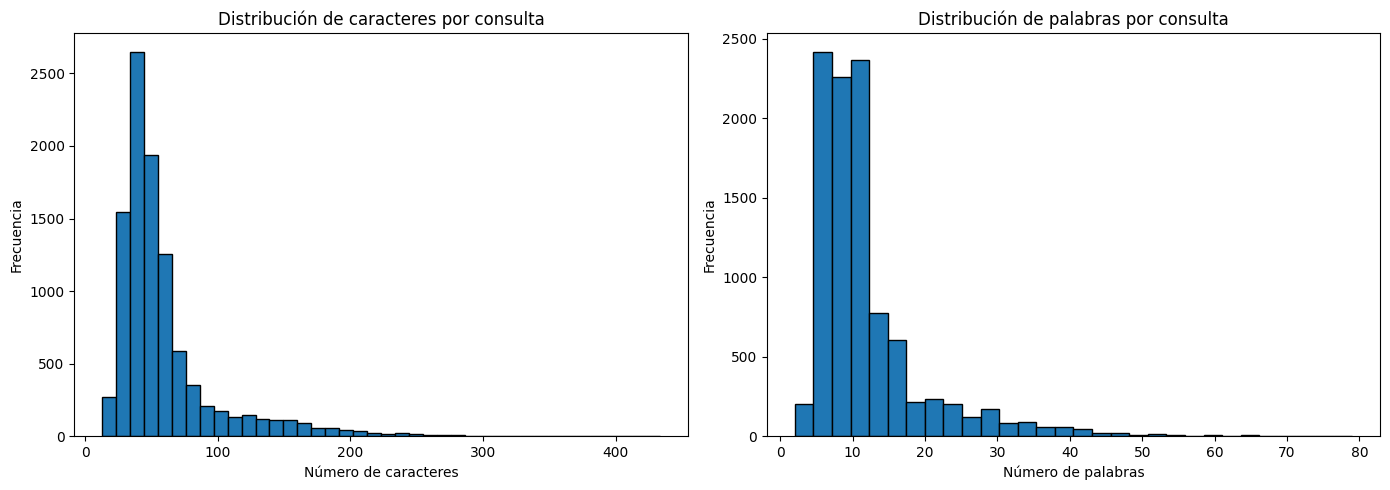

In [ ]:
# Distribución de la longitud de las consultas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de caracteres
axes[0].hist(df_train["num_caracteres"], bins=40, edgecolor="black")
axes[0].set_title("Distribución de caracteres por consulta")
axes[0].set_xlabel("Número de caracteres")
axes[0].set_ylabel("Frecuencia")

# Histograma de palabras
axes[1].hist(df_train["num_palabras"], bins=30, edgecolor="black")
axes[1].set_title("Distribución de palabras por consulta")
axes[1].set_xlabel("Número de palabras")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Interpretación de la distribucion**

Las graficas confirman que la distribucion de la longitud está sesgada hacia la derecha. La mayor parte de las consultas de concentran en textos breves, mientras que existe un número reducido de consultas considerablemente más largas.

Esta variablidad puede influir en la clasificación: las consultas muy breves ofrecen menos contexto para identificar la intención, mientras que las consultas largas continenmas información, pero tambien pueden incluir terminos que no sean esenciales para determinar la categoría. estos resultados tambien serán consideragos al definir la longitud máxima utilizada durante la tokenización.

In [ ]:
# Consulta más corta
consulta_corta = df_train.loc[df_train["num_palabras"].idxmin()]

print("CONSULTA MÁS CORTA")
print("Texto:", consulta_corta["text"])
print("Categoría:", consulta_corta["category"])
print("Palabras:", consulta_corta["num_palabras"])

print("\n" + "-" * 80 + "\n")

# Consulta más larga
consulta_larga = df_train.loc[df_train["num_palabras"].idxmax()]

print("CONSULTA MÁS LARGA")
print("Texto:", consulta_larga["text"])
print("Categoría:", consulta_larga["category"])
print("Palabras:", consulta_larga["num_palabras"])

CONSULTA MÁS CORTA
Texto: Cancel Transaction
Categoría: cancel_transfer
Palabras: 2

--------------------------------------------------------------------------------

CONSULTA MÁS LARGA
Texto: Hearing back from us regarding your important verification results may take 10 minutes to one hour time.  If verification results do fail, double-check to make sure all of your images are clear --  make sure your photos have no glare or blurring. Note: These photos need to be readable as well.  You also need to be 18 years of age or older.  You must be a resident of Switzerland or the European Economic Area to open a new account.
Categoría: unable_to_verify_identity
Palabras: 79


In [ ]:
# Descargamos la lista de stopwords en inglés
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Número de stopwords:", len(stop_words))
print("Ejemplos:", list(stop_words)[:20])

Número de stopwords: 198
Ejemplos: ['off', 'both', 'wasn', 'only', 's', "he's", 'now', 'our', 'isn', 'ourselves', 'your', "weren't", 'than', 'yourself', "he'll", 'those', 'ma', 'who', 'shan', 're']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Función utilizada únicamente para el análisis exploratorio
def limpiar_texto(texto):
    # Convertimos a minúsculas
    texto = texto.lower()

    # Eliminamos caracteres especiales y conservamos letras y espacios
    texto = re.sub(r"[^a-z\s]", " ", texto)

    # Eliminamos stopwords
    palabras = texto.split()
    palabras = [
        palabra for palabra in palabras
        if palabra not in stop_words
    ]

    # Reconstruimos el texto
    return " ".join(palabras)


# Creamos una nueva columna sin modificar el texto original
df_train["text_clean"] = df_train["text"].apply(limpiar_texto)

df_train[["text", "text_clean"]].head(10)

,text,text_clean
0,I am still waiting on my card?,still waiting card
1,What can I do if my card still hasn't arrived ...,card still arrived weeks
2,I have been waiting over a week. Is the card s...,waiting week card still coming
3,Can I track my card while it is in the process...,track card process delivery
4,"How do I know if I will get my card, or if it ...",know get card lost
5,When did you send me my new card?,send new card
6,Do you have info about the card on delivery?,info card delivery
7,What do I do if I still have not received my n...,still received new card
8,Does the package with my card have tracking?,package card tracking
9,I ordered my card but it still isn't here,ordered card still


### 3.3 Palabras más frecuentes

A partir del texto limpio se identifican las palabras con mayor frecuencia en el
conjunto de entrenamiento. Este análisis permite conocer los términos predominantes en las consultas bancarias y detectar vocabulario que puede aparecer en múltiples
categorías.

In [ ]:
# Importamos Counter para contar la frecuencia de las palabras
from collections import Counter

# Unimos todas las consultas limpias y las dividimos en palabras
todas_palabras = " ".join(df_train["text_clean"]).split()

# Contamos cuántas veces aparece cada palabra
frecuencia_palabras = Counter(todas_palabras)

# Obtenemos las 15 palabras más frecuentes
top_15_palabras = frecuencia_palabras.most_common(15)

top_15_palabras

[('card', 2682),
 ('account', 1352),
 ('money', 1133),
 ('transfer', 1084),
 ('top', 1045),
 ('get', 808),
 ('payment', 751),
 ('need', 698),
 ('cash', 691),
 ('exchange', 549),
 ('charged', 529),
 ('please', 515),
 ('atm', 482),
 ('app', 469),
 ('fee', 458)]

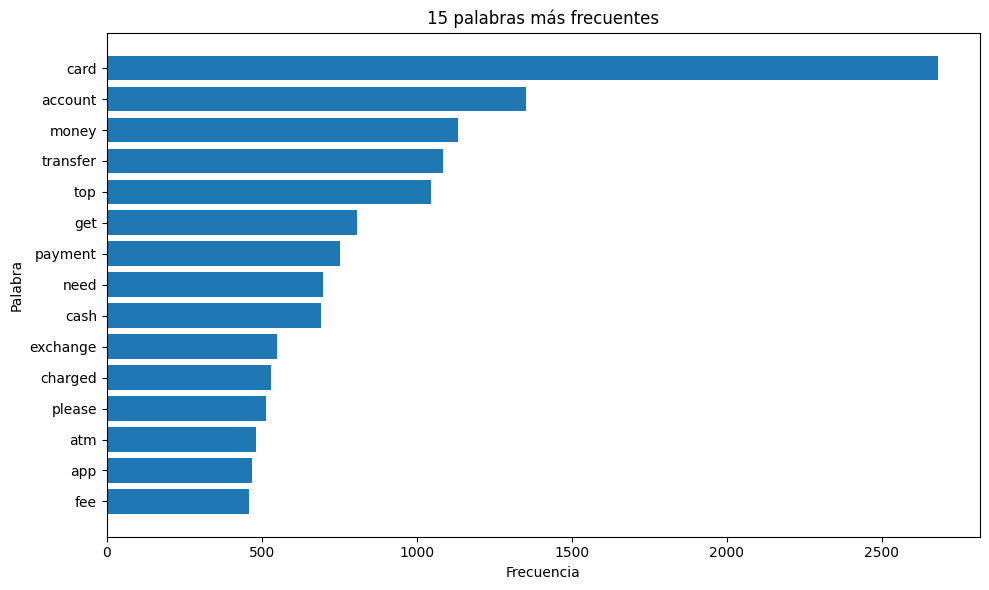

In [ ]:
# Convertimos el resultado a un DataFrame para facilitar la visualización
df_top_palabras = pd.DataFrame(
    top_15_palabras,
    columns=["palabra", "frecuencia"]
)

# Gráfica de las 15 palabras más frecuentes
plt.figure(figsize=(10, 6))

plt.barh(
    df_top_palabras["palabra"][::-1],
    df_top_palabras["frecuencia"][::-1]
)

plt.title("15 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
plt.show()

**Interpretación**

Las palabras más frecuentes están relacionadas directamente con operaciones y servicios bancarios. Destaca especialmente 'card', seguida de terminos como 'account', 'money', 'transfer', 'payment' y 'cash'.

La elevada frecuencia de algunos terminos, indica que una misma palabra puede aparecer en consultas pertenecientes a diferentes categorias. Por ejemplo, la presencia de 'card' por si sola, no es suficiente para identificar una intención ya que puede estar la misma palabra puede estar relacionada con activacion, entrega, perdida, o problemas de pago.

Para la clasificación será importante considerar el contexto y las combinaciones de palabras, y no unicamente la presencia de términos individuales.

### 3.4 Bigramas y trigramas más frecuentes

Además de analizar palabras individuales, se estudian las combinaciones de dos
y tres palabras consecutivas más frecuentes. Esto permite identificar expresiones
que aportan mayor contexto sobre las intenciones presentes en las consultas.

In [ ]:
from nltk.util import ngrams

# Listas donde almacenaremos los bigramas y trigramas
todos_bigramas = []
todos_trigramas = []

# Generamos los n-gramas de cada consulta de manera independiente
for texto in df_train["text_clean"]:
    palabras = texto.split()

    todos_bigramas.extend(ngrams(palabras, 2))
    todos_trigramas.extend(ngrams(palabras, 3))

# Contamos sus frecuencias
frecuencia_bigramas = Counter(todos_bigramas)
frecuencia_trigramas = Counter(todos_trigramas)

# Seleccionamos los 10 más frecuentes
top_10_bigramas = frecuencia_bigramas.most_common(10)
top_10_trigramas = frecuencia_trigramas.most_common(10)

print("10 BIGRAMAS MÁS FRECUENTES")
for bigrama, frecuencia in top_10_bigramas:
    print(" ".join(bigrama), "-", frecuencia)

print("\n10 TRIGRAMAS MÁS FRECUENTES")
for trigrama, frecuencia in top_10_trigramas:
    print(" ".join(trigrama), "-", frecuencia)

10 BIGRAMAS MÁS FRECUENTES
exchange rate - 293
new card - 225
card payment - 202
virtual card - 181
would like - 166
cash withdrawal - 165
money account - 130
please help - 122
long take - 121
still pending - 119

10 TRIGRAMAS MÁS FRECUENTES
disposable virtual card - 63
exchange rate wrong - 41
get money back - 36
charged extra fee - 33
direct debit payment - 33
get new card - 31
transfer money account - 29
get virtual card - 28
exchange rate applied - 27
would like know - 26


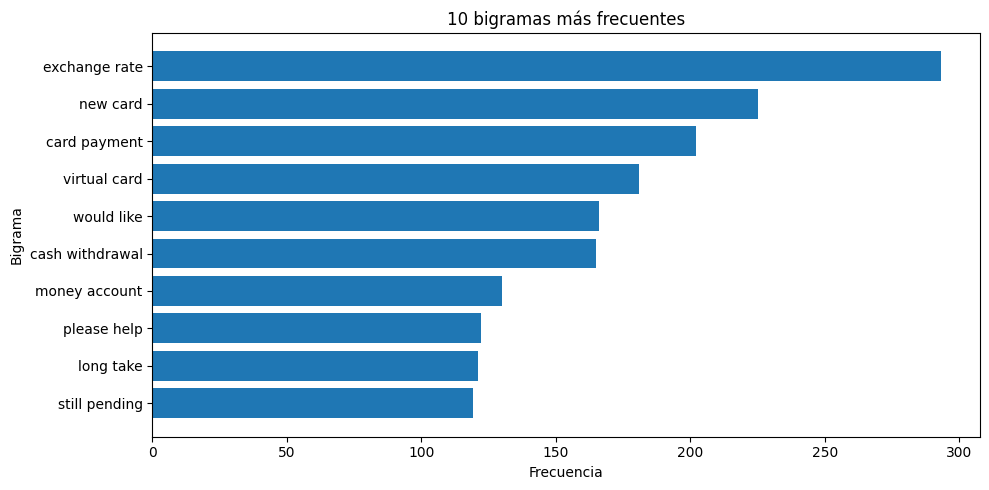

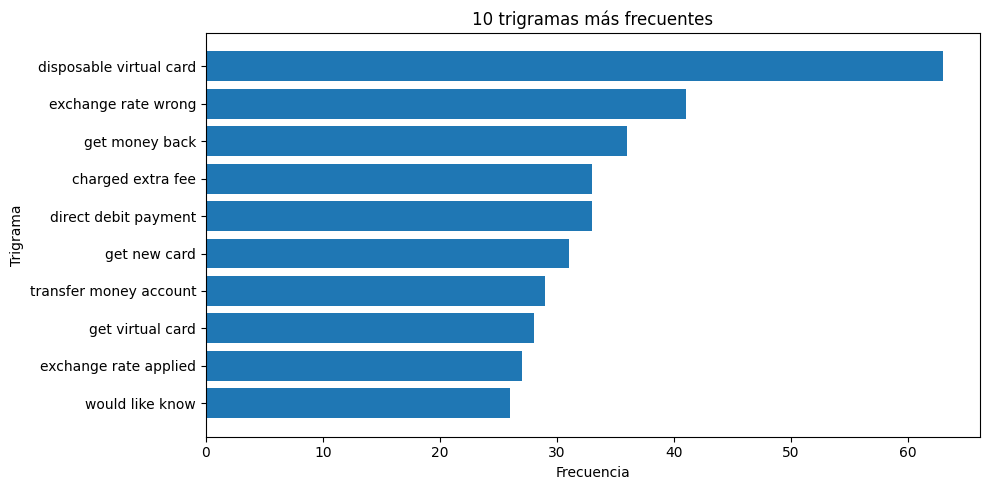

In [ ]:
# Preparamos los resultados para graficarlos
df_bigramas = pd.DataFrame(
    [(" ".join(x), freq) for x, freq in top_10_bigramas],
    columns=["bigrama", "frecuencia"]
)

df_trigramas = pd.DataFrame(
    [(" ".join(x), freq) for x, freq in top_10_trigramas],
    columns=["trigrama", "frecuencia"]
)

# Gráfica de bigramas
plt.figure(figsize=(10, 5))
plt.barh(
    df_bigramas["bigrama"][::-1],
    df_bigramas["frecuencia"][::-1]
)
plt.title("10 bigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Bigrama")
plt.tight_layout()
plt.show()

# Gráfica de trigramas
plt.figure(figsize=(10, 5))
plt.barh(
    df_trigramas["trigrama"][::-1],
    df_trigramas["frecuencia"][::-1]
)
plt.title("10 trigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Trigrama")
plt.tight_layout()
plt.show()

**Interpretación**

El análisis de bigramas y trigramas aporta mayor información que el de palabras individuales. Mientras que términos como 'card', 'money' o 'exchange' pueden aparecer en diferentes tipos de consultas, combinaciones como ' exchange rate', 'virtual card', 'cash withdrawal' o 'still pending' describen intenciones especificas.

Los trigramas aumentan todavía mas el contexto. Expresiones como 'disposable virtual card', 'exvhange rate wrong', 'cash withdrawal fee' y 'direct debit payment' están directamente relacionadas con situaciones bancarias concretas.

Estos resultados sugieren que el contexto y la relación entre palabras serán importantes para diferenciar las 77 categorías. Esto resulta especialmente relevante para el uso de un modelo Transformer, ya que este tipo de modelo analiza las palabras considerando el contexto en el que aparecen y no unicamente como términos aislados.

### 3.5 Nube de palabras

Se genera una nube de palabras a partir del texto procesado para visualizar de forma
general los términos con mayor presencia en las consultas del conjunto de entrenamiento.
El tamaño de cada palabra representa su frecuencia relativa.

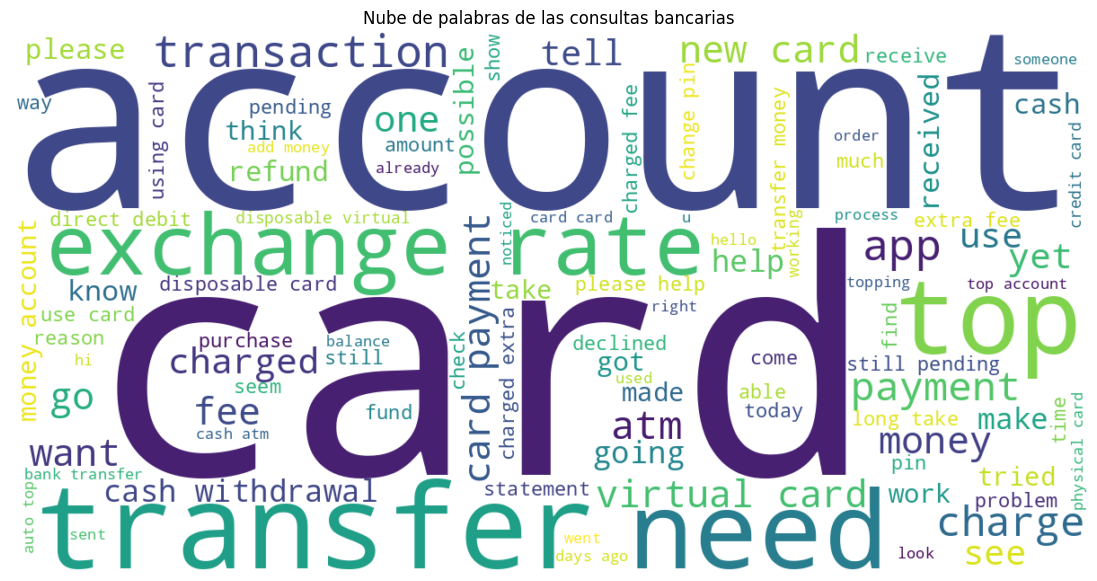

In [ ]:
# Unimos todas las consultas limpias en un único texto
texto_completo = " ".join(df_train["text_clean"])

# Generamos la nube de palabras
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    random_state=SEED
).generate(texto_completo)

# Mostramos la nube
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de las consultas bancarias")
plt.show()

### 3.6 Distribución y balance de las clases

Se analiza el número de consultas correspondiente a cada una de las 77 categorías para determinar si el conjunto de entrenamiento presenta un desbalance importante entre las clases.

In [ ]:
# Contamos el número de consultas de cada categoría
distribucion_clases = (
    df_train["category"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Número de clases:", len(distribucion_clases))
print("Clase con más ejemplos:")
print(distribucion_clases.head(1))

print("\nClase con menos ejemplos:")
print(distribucion_clases.tail(1))

print("\nEstadísticas de la distribución:")
print(distribucion_clases.describe())

Número de clases: 77
Clase con más ejemplos:
category
card_payment_fee_charged    187
Name: count, dtype: int64

Clase con menos ejemplos:
category
contactless_not_working    35
Name: count, dtype: int64

Estadísticas de la distribución:
count     77.000000
mean     129.909091
std       32.942207
min       35.000000
25%      112.000000
50%      127.000000
75%      159.000000
max      187.000000
Name: count, dtype: float64


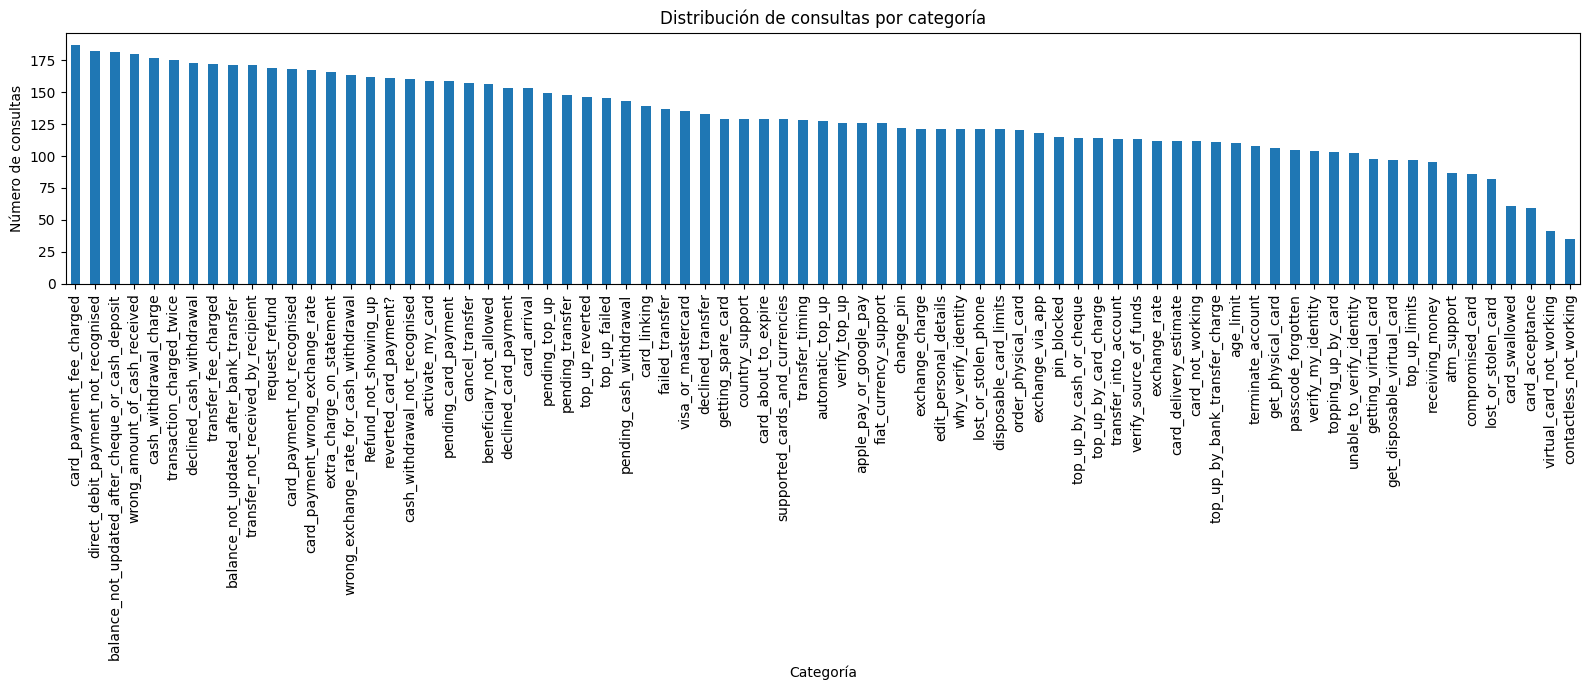

In [ ]:
# Distribución de las 77 categorías
plt.figure(figsize=(16, 7))

distribucion_clases.plot(kind="bar")

plt.title("Distribución de consultas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de consultas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Interpretación de la distribución de clases**

Las 77 categorías contienen en promedio aproximadamente 130 consultas de entrenamiento. Sin embargo, la distribución no es completamente uniforme: la categoría con mayor representación es 'card_payment_fee_charged', con 187 ejemplos, mientras que 'contactless_not_working' presenta solamente 35.

Por tanto, existe cierto desvalance entre las categorías. Esta diferencia podría influir en el aprendizaje del clasificador, especialmente en las clases con menos ejemplos. Durante la evaluación será importante comprobar si las categorías menos representadas presentan también valores inferiores de precision, recall o F1-score.

### 3.7 Conclusiones del análisis exploratorio

El analisis exploratorio muestra que Bnaking77 está formado principalmente por consultas breves. La consulta promedio contiene aproximadamente 12 palabras y el 75% de los textos tiene 13 palabras o menos, aunque existen algunos cassos considerablemente mas largos.

El vocabulario esta dominado por términos  bancarios generales como 'card', 'account', 'money', 'transfer' y 'payment'. Sin embargo, el analisis de bigramas y trigramas muestra que combinaciones como 'exchange rate', 'cash withdrawal', 'virtual card', 'exchange rate wrong' o 'cash withdrawal fee' aportan mayor información sobre la intención correcta de una consulta. Esto sugiere que para distinguir las 77 categorías será importante considerar el contexto y las relaciones entre las palabras.

Tambien se identificó un desbalance moderado entre las cateorías. Aunque la media es de aproximadamente 130 ejemplos por clase, el número de consultas varía entre 35 y 187. Por esta razón, además del accuracy global, será necesario analizar precision, recall y F1-score por categoría para comprobar si las clases menos representadas presentan mayores dificultades de clasificación.

Estos resultados justifican el uso de un modelo Transformer como DistilToBERTa, capaz de representar las palabras considerando su contexto. Ademas, el análisis exploratorio servirá posteriormente como referencia para interpretar las clases con mayor número de errores.

## 4. Clasificación con DistilRoBERTa

Se utilizará un modelo DistilRoBERTa preentrenado y se realizará fine-tuning para
clasificar las consultas de Banking77 entre sus 77 categorías.

Para evitar utilizar el conjunto de prueba durante el entrenamiento, se separará
una parte del conjunto de entrenamiento original para validación. El conjunto de
prueba se reservará para la evaluación final del modelo.

In [ ]:
# Dividimos el conjunto original de entrenamiento en train y validación.
# Se utiliza una semilla fija para favorecer la reproducibilidad.

train_validation = dataset["train"].train_test_split(
    test_size=0.10,
    seed=SEED,
    stratify_by_column="label"
)

train_dataset = train_validation["train"]
val_dataset = train_validation["test"]
test_dataset = dataset["test"]

print("Entrenamiento:", len(train_dataset))
print("Validación:", len(val_dataset))
print("Prueba:", len(test_dataset))
print("Total:", len(train_dataset) + len(val_dataset) + len(test_dataset))

Entrenamiento: 9002
Validación: 1001
Prueba: 3080
Total: 13083


### 4.1 Tokenización

Antes de introducir las consultas al modelo, el texto debe transformarse a una
representación numérica. Para ello se utiliza el tokenizer correspondiente a
DistilRoBERTa, que divide el texto en tokens y los convierte en identificadores
numéricos que pueden ser procesados por la red neuronal.

In [ ]:
from transformers import AutoTokenizer

# Cargamos el tokenizer asociado a DistilRoBERTa
MODEL_NAME = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
# Seleccionamos una consulta de ejemplo
ejemplo = train_dataset[0]["text"]

print("Texto original:")
print(ejemplo)

Texto original:
I want to use auto top-up. Is there a limit?


In [ ]:
# Tokenizamos una sola consulta para observar el proceso
tokens = tokenizer.tokenize(ejemplo)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Texto original:")
print(ejemplo)

print("\nTokens:")
print(tokens)

print("\nIDs:")
print(token_ids)

print("\nNúmero de palabras:", len(ejemplo.split()))
print("Número de tokens:", len(tokens))

Texto original:
I want to use auto top-up. Is there a limit?

Tokens:
['I', 'Ġwant', 'Ġto', 'Ġuse', 'Ġauto', 'Ġtop', '-', 'up', '.', 'ĠIs', 'Ġthere', 'Ġa', 'Ġlimit', '?']

IDs:
[100, 236, 7, 304, 4485, 299, 12, 658, 4, 1534, 89, 10, 3000, 116]

Número de palabras: 10
Número de tokens: 14


In [ ]:
# Codificación completa utilizada por el modelo
codificacion = tokenizer(
    ejemplo,
    truncation=True,
    max_length=128
)

print("input_ids:")
print(codificacion["input_ids"])

print("\nattention_mask:")
print(codificacion["attention_mask"])

print("\nNúmero total de tokens:", len(codificacion["input_ids"]))

input_ids:
[0, 100, 236, 7, 304, 4485, 299, 12, 658, 4, 1534, 89, 10, 3000, 116, 2]

attention_mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Número total de tokens: 16


### 4.2 Longitud de las secuencias tokenizadas

Antes de establecer la longitud maxima de entrada del modelo, se analiza el número de tokens generado por el tokenizer de DistilRoBERTa. Asi, el valor de 'max_length' se puede seleccionar a partir de las características reales del dataset y no de forma arbitraria.

In [ ]:
# Calculamos el número de tokens de cada consulta, incluyendo tokens especiales
longitudes_tokens = []

for texto in dataset["train"]["text"]:
    codificacion = tokenizer(
        texto,
        add_special_tokens=True,
        truncation=False
    )

    longitudes_tokens.append(len(codificacion["input_ids"]))

# Resumen estadístico
serie_tokens = pd.Series(longitudes_tokens)

print("Estadísticas de longitud en tokens:")
print(serie_tokens.describe())

print("\nPercentil 90:", np.percentile(longitudes_tokens, 90))
print("Percentil 95:", np.percentile(longitudes_tokens, 95))
print("Percentil 99:", np.percentile(longitudes_tokens, 99))
print("Máximo:", max(longitudes_tokens))

Estadísticas de longitud en tokens:
count    10003.000000
mean        15.800360
std          9.027776
min          4.000000
25%         11.000000
50%         13.000000
75%         17.000000
max         96.000000
dtype: float64

Percentil 90: 27.0
Percentil 95: 36.0
Percentil 99: 51.0
Máximo: 96


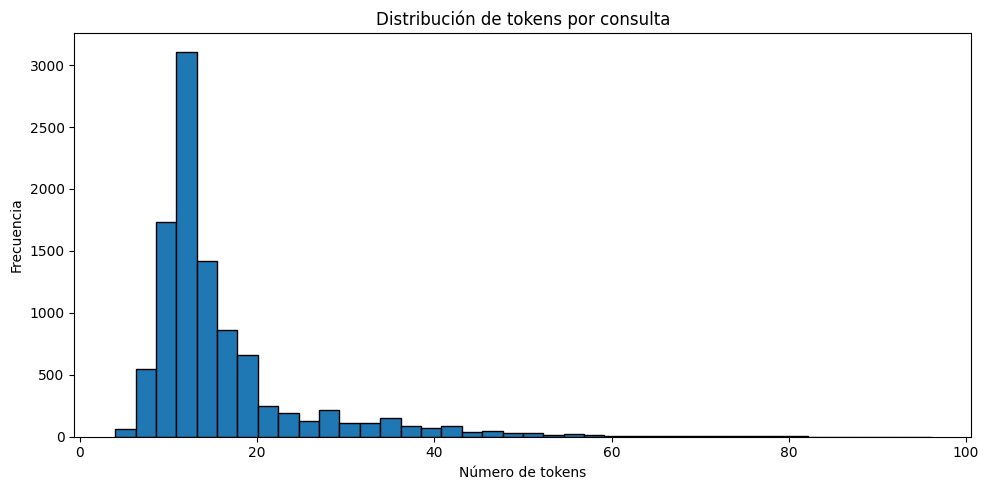

In [ ]:
# Distribución de la longitud de las consultas después de tokenizarlas
plt.figure(figsize=(10, 5))

plt.hist(longitudes_tokens, bins=40, edgecolor="black")

plt.title("Distribución de tokens por consulta")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [ ]:
# Comprobamos cuántas consultas superan la longitud seleccionada
superan_max = sum(longitud > 64 for longitud in longitudes_tokens)

print("Consultas con más de 64 tokens:", superan_max)
print(
    "Porcentaje:",
    round(superan_max / len(longitudes_tokens) * 100, 2),
    "%"
)

Consultas con más de 64 tokens: 28
Porcentaje: 0.28 %


**Selección de la longitud máxima**

La tokenización confirma que las consultas de Banking77 son generalmente breves.
La longitud media es de aproximadamente 16 tokens, el 95% de las consultas contiene 36 tokens o menos y el 99% se sitúa en 51 tokens.

A partir de estos resultados se seleccionó 'max_length = 64'. Solamente 28 de las 10,003 consultas de entrenamiento (0.28 %) superan esta longitud, por lo que el 99.72% puede representarse sin truncamiento. Este valor permite conservar prácticamente toda la información y, al mismo tiempo, reducir el uso innecesario de memoria y cómputo durante el entrenamiento.

In [ ]:
MAX_LENGTH = 64

def tokenizar(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
# Tokenizamos entrenamiento, validación y prueba
train_tokenized = train_dataset.map(
    tokenizar,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenizar,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenizar,
    batched=True
)

print(train_tokenized)
print(val_tokenized)
print(test_tokenized)

Map:   0%|          | 0/9002 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 9002
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 1001
})
Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 3080
})


In [ ]:
ejemplo_tokenizado = train_tokenized[0]

print("Texto original:")
print(ejemplo_tokenizado["text"])

print("\nEtiqueta:")
print(ejemplo_tokenizado["label"])
print(class_names[ejemplo_tokenizado["label"]])

print("\ninput_ids:")
print(ejemplo_tokenizado["input_ids"])

print("\nattention_mask:")
print(ejemplo_tokenizado["attention_mask"])

Texto original:
I want to use auto top-up. Is there a limit?

Etiqueta:
4
automatic_top_up

input_ids:
[0, 100, 236, 7, 304, 4485, 299, 12, 658, 4, 1534, 89, 10, 3000, 116, 2]

attention_mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### 4.3 Métricas de evaluación

Para evaluar el modelo se utilizarán accuracy, precision, recall y F1-score.
Debido a que se trata de un problema multiclase con 77 categorías y existe cierto desbalance entre ellas, además de las métricas globales se analizarán posteriormente los resultados por categoría y la matriz de confusión.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Seleccionamos la clase con mayor puntuación
    predictions = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_score(labels, predictions)

    # Precision, recall y F1 macro
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
from transformers import DataCollatorWithPadding

# El padding se realizará dinámicamente según la consulta más larga de cada batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

num_labels = len(class_names)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: clase for i, clase in enumerate(class_names)},
    label2id={clase: i for i, clase in enumerate(class_names)}
)

print("Número de categorías:", model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Número de categorías: 77


In [ ]:
# Número de parámetros del modelo
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales: 82,177,613
Parámetros entrenables: 82,177,613


### 4.4 Configuración del entrenamiento

El modelo se ajustará mediante fine-tuning utilizando el conjunto de entrenamiento,
mientras que el conjunto de validación se empleará para evaluar su desempeño durante
el proceso y seleccionar el mejor checkpoint.

Se utilizará una tasa de aprendizaje reducida, adecuada para modificar gradualmente
los pesos de un modelo preentrenado. Como métrica para seleccionar el mejor modelo
se utilizará F1 macro, de modo que las 77 categorías tengan el mismo peso en la
evaluación independientemente de su número de ejemplos.

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilroberta_banking77",

    # Entrenamiento
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Tamaño de batch
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Evaluación y guardado al finalizar cada epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # Selección del mejor checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    # Reproducibilidad
    seed=SEED,
    data_seed=SEED,

    # Registro
    logging_strategy="steps",
    logging_steps=100,
    report_to="none",

    # Evitamos conservar demasiados checkpoints
    save_total_limit=2
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
from transformers import EarlyStoppingCallback

# Detiene el entrenamiento si la métrica de validación
# no mejora durante 2 evaluaciones consecutivas.
trainer.add_callback(
    EarlyStoppingCallback(
        early_stopping_patience=2
    )
)

### 4.5 Fine-tuning de DistilRoBERTa

Se realiza el fine-tuning del modelo durante un máximo de tres épocas. Al finalizar cada época se evalúa el desempeño sobre el conjunto de validación utilizando accuracy, precision, recall y F1 macro.

El mejor checkpoint se selecciona de acuerdo con F1 macro. También se utiliza Early Stopping para detener el entrenamiento si la métrica deja de mejorar durante dos evaluaciones consecutivas.

In [ ]:
# Entrenamiento del modelo
resultado_entrenamiento = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,2.061187,1.521253,0.770230,0.743942,0.735516,0.713941
2,1.061955,0.870906,0.855145,0.865669,0.835472,0.834305
3,0.843230,0.734277,0.867133,0.869729,0.850710,0.850093


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Resultados del entrenamiento**

El modelo mejoró progresivamente durante las tres épocas. El F1 macro de validación aumentó de 71.39% en la primera época a 83.43 % en la segunda y 85.01% en la tercera. De manera similar, el accuracy aumentó de 77.02 % a 86.71 %.

Al mismo tiempo, tanto la pérdida de entrenamiento como la pérdida de validación
disminuyeron durante las tres épocas. Por lo tanto, no se observa una señal clara de sobreajuste durante el entrenamiento realizado.

La tercera época obtuvo el mayor F1 macro y fue seleccionada como el mejor checkpoint.

In [ ]:
# Evaluamos nuevamente el mejor checkpoint sobre validación
metricas_validacion = trainer.evaluate(val_tokenized)

metricas_validacion

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.843230,0.734277,3,0.867133,0.869729,0.850710,0.850093


{'eval_loss': 0.7342773079872131,
 'eval_accuracy': 0.8671328671328671,
 'eval_precision_macro': 0.8697293956863554,
 'eval_recall_macro': 0.8507099430820833,
 'eval_f1_macro': 0.8500933686459595}

In [ ]:
# Evaluación final sobre el conjunto de prueba
metricas_test = trainer.evaluate(test_tokenized)

metricas_test

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.843230,0.779896,3,0.868182,0.870884,0.868182,0.860935


{'eval_loss': 0.7798962593078613,
 'eval_accuracy': 0.8681818181818182,
 'eval_precision_macro': 0.870884086790054,
 'eval_recall_macro': 0.8681818181818183,
 'eval_f1_macro': 0.8609352798507627}

### 4.6 Análisis de resultados por categoría

Además de las métricas globales, se analizan las predicciones individuales del
conjunto de prueba para estudiar el desempeño del modelo en cada una de las 77
categorías.

Se calculan precision, recall y F1-score por clase y se construye una matriz de
confusión para identificar las categorías que presentan mayores dificultades y
los errores sistemáticos del clasificador.

In [ ]:
# Obtenemos las predicciones del mejor modelo sobre el conjunto de prueba
predicciones_test = trainer.predict(test_tokenized)

# Logits generados por el modelo
logits_test = predicciones_test.predictions

# Etiquetas reales
y_true = predicciones_test.label_ids

# Convertimos los logits en la clase predicha
y_pred = np.argmax(logits_test, axis=-1)

print("Número de predicciones:", len(y_pred))
print("Número de etiquetas reales:", len(y_true))
print("\nPrimeras 10 etiquetas reales:")
print(y_true[:10])
print("\nPrimeras 10 predicciones:")
print(y_pred[:10])

Número de predicciones: 3080
Número de etiquetas reales: 3080

Primeras 10 etiquetas reales:
[11 11 11 11 11 11 11 11 11 11]

Primeras 10 predicciones:
[43 11 11 12 11 12 11 11 11 11]


In [ ]:
from sklearn.metrics import classification_report

# Reporte completo por categoría
reporte = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(reporte)

                                                  precision    recall  f1-score   support

                                activate_my_card     1.0000    0.9500    0.9744        40
                                       age_limit     0.9524    1.0000    0.9756        40
                         apple_pay_or_google_pay     0.9756    1.0000    0.9877        40
                                     atm_support     1.0000    1.0000    1.0000        40
                                automatic_top_up     1.0000    0.8750    0.9333        40
         balance_not_updated_after_bank_transfer     0.7442    0.8000    0.7711        40
balance_not_updated_after_cheque_or_cash_deposit     0.9512    0.9750    0.9630        40
                         beneficiary_not_allowed     0.7778    0.7000    0.7368        40
                                 cancel_transfer     0.9500    0.9500    0.9500        40
                            card_about_to_expire     0.9512    0.9750    0.9630        40
         

In [ ]:
# Generamos el reporte como diccionario
reporte_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Lo convertimos en DataFrame
df_reporte = pd.DataFrame(reporte_dict).T

# Conservamos únicamente las 77 categorías
df_clases = df_reporte.loc[class_names].copy()

df_clases.head()

,precision,recall,f1-score,support
activate_my_card,1.000000,0.950,0.974359,40.0
age_limit,0.952381,1.000,0.975610,40.0
apple_pay_or_google_pay,0.975610,1.000,0.987654,40.0
atm_support,1.000000,1.000,1.000000,40.0
automatic_top_up,1.000000,0.875,0.933333,40.0


In [ ]:
# 7 categorías con mayor F1-score
mejores_7 = df_clases.sort_values(
    by="f1-score",
    ascending=False
).head(7)

print("7 CLASES CON MAYOR F1-SCORE")
display(
    mejores_7[["precision", "recall", "f1-score", "support"]]
)

7 CLASES CON MAYOR F1-SCORE


,precision,recall,f1-score,support
atm_support,1.000000,1.000,1.000000,40.0
verify_source_of_funds,1.000000,1.000,1.000000,40.0
edit_personal_details,1.000000,1.000,1.000000,40.0
apple_pay_or_google_pay,0.975610,1.000,0.987654,40.0
lost_or_stolen_phone,1.000000,0.975,0.987342,40.0
passcode_forgotten,0.952381,1.000,0.975610,40.0
age_limit,0.952381,1.000,0.975610,40.0


In [ ]:
from sklearn.metrics import confusion_matrix

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Número de ejemplos correctamente clasificados por clase
aciertos_por_clase = np.diag(cm)

# Total real de ejemplos por clase
total_por_clase = cm.sum(axis=1)

# Errores por clase
errores_por_clase = total_por_clase - aciertos_por_clase

df_errores = pd.DataFrame({
    "categoria": class_names,
    "total_test": total_por_clase,
    "aciertos": aciertos_por_clase,
    "errores": errores_por_clase
})

peores_7 = df_errores.sort_values(
    by="errores",
    ascending=False
).head(7)

print("7 CLASES CON MAYOR NÚMERO DE ERRORES")
display(peores_7)

7 CLASES CON MAYOR NÚMERO DE ERRORES


,categoria,total_test,aciertos,errores
72,virtual_card_not_working,40,0,40
74,why_verify_identity,40,14,26
18,card_swallowed,40,16,24
10,card_acceptance,40,24,16
56,top_up_by_bank_transfer_charge,40,26,14
22,compromised_card,40,27,13
62,topping_up_by_card,40,27,13


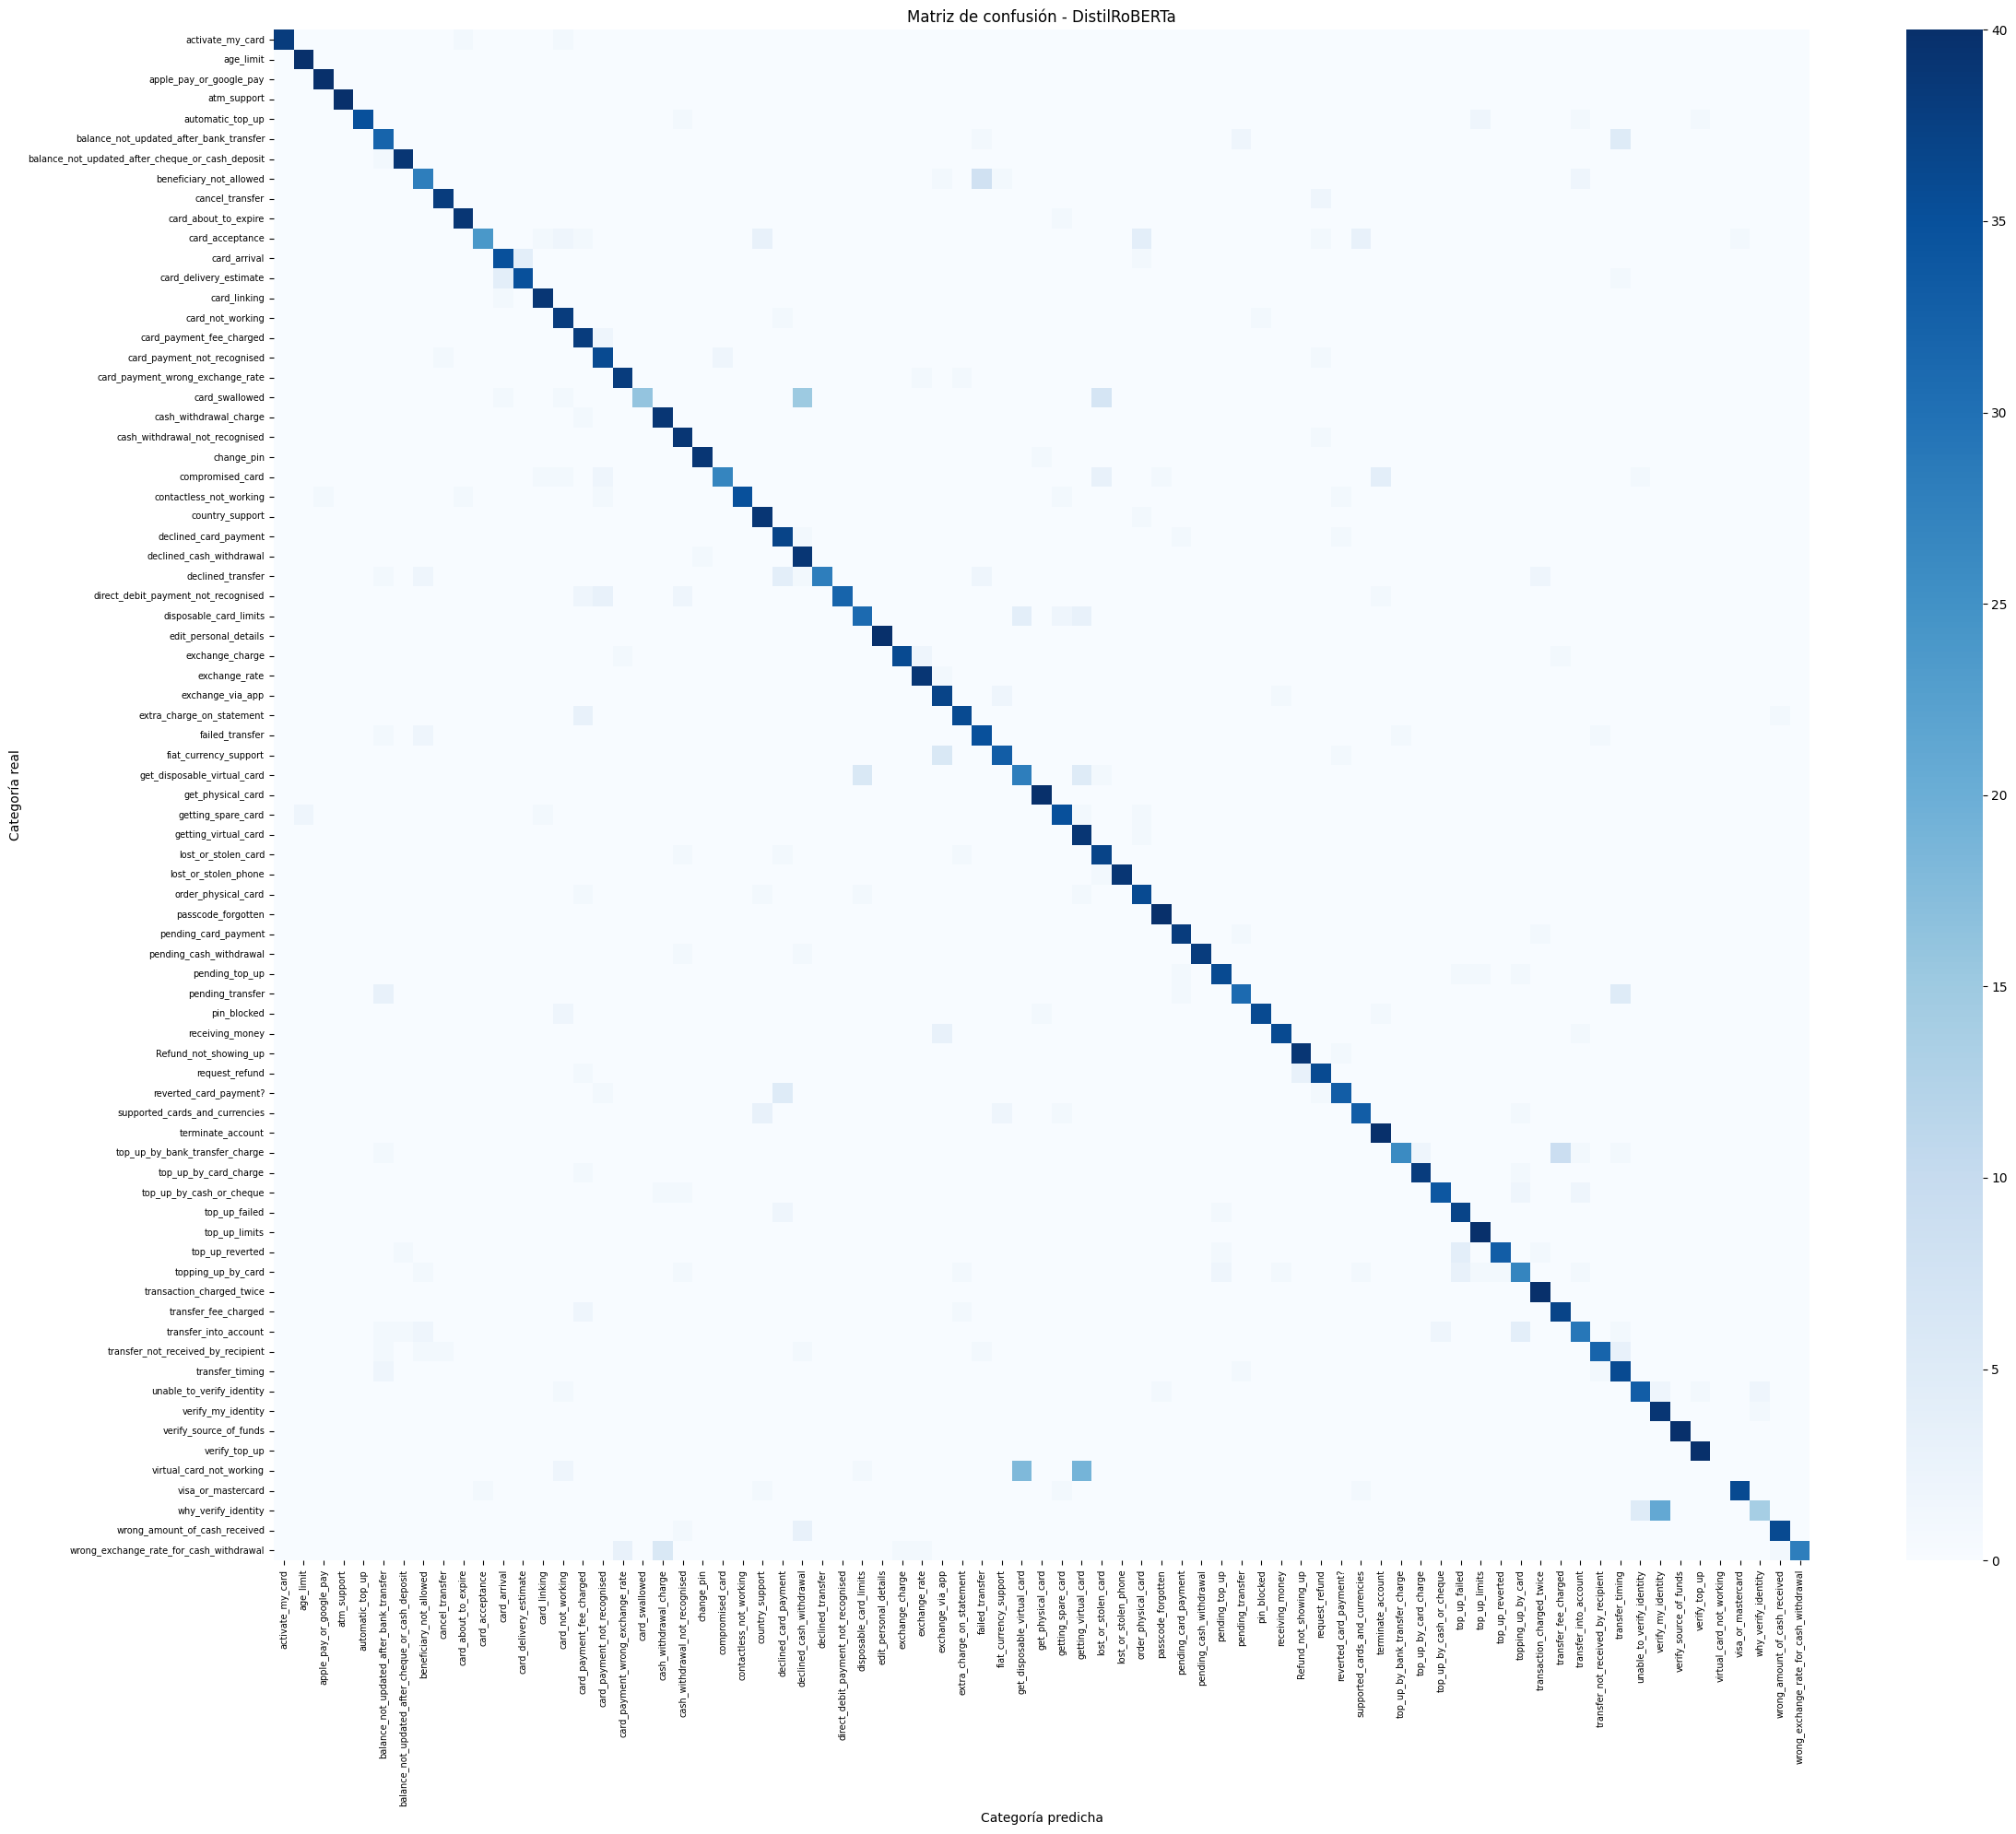

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(24, 20))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title("Matriz de confusión - DistilRoBERTa")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

### 4.7 Análisis de las clases con mayor número de errores

Aunque el modelo presenta un buen desempeño global, existen diferencias importantes entre categorías. Por ello se analizan las clases con mayor número de errores y las categorías con las que son confundidas con mayor frecuencia.

In [ ]:
# Analizamos con qué categorías se confunden las 7 clases
# que presentan mayor número de errores.

for categoria in peores_7["categoria"]:
    idx = class_names.index(categoria)

    fila = cm[idx].copy()

    # Eliminamos los aciertos para mostrar únicamente errores
    fila[idx] = 0

    indices_confusion = np.argsort(fila)[::-1]

    print(f"\nREAL: {categoria}")
    print("-" * 60)

    mostrados = 0

    for j in indices_confusion:
        if fila[j] > 0:
            print(
                f"Predicha como {class_names[j]}: "
                f"{fila[j]} casos"
            )
            mostrados += 1

        if mostrados == 5:
            break


REAL: virtual_card_not_working
------------------------------------------------------------
Predicha como getting_virtual_card: 19 casos
Predicha como get_disposable_virtual_card: 18 casos
Predicha como card_not_working: 2 casos
Predicha como disposable_card_limits: 1 casos

REAL: why_verify_identity
------------------------------------------------------------
Predicha como verify_my_identity: 21 casos
Predicha como unable_to_verify_identity: 5 casos

REAL: card_swallowed
------------------------------------------------------------
Predicha como declined_cash_withdrawal: 15 casos
Predicha como lost_or_stolen_card: 7 casos
Predicha como card_not_working: 1 casos
Predicha como card_arrival: 1 casos

REAL: card_acceptance
------------------------------------------------------------
Predicha como order_physical_card: 4 casos
Predicha como supported_cards_and_currencies: 3 casos
Predicha como country_support: 3 casos
Predicha como card_not_working: 2 casos
Predicha como visa_or_mastercard:

In [ ]:
# Creamos un DataFrame con todas las predicciones del conjunto de prueba

df_predicciones = pd.DataFrame({
    "texto": test_dataset["text"],
    "real_id": y_true,
    "pred_id": y_pred
})

df_predicciones["categoria_real"] = df_predicciones["real_id"].apply(
    lambda x: class_names[x]
)

df_predicciones["categoria_predicha"] = df_predicciones["pred_id"].apply(
    lambda x: class_names[x]
)

df_predicciones["correcta"] = (
    df_predicciones["real_id"] == df_predicciones["pred_id"]
)

# Nos quedamos únicamente con los errores
df_errores_test = df_predicciones[
    ~df_predicciones["correcta"]
].copy()

print("Total de consultas de prueba:", len(df_predicciones))
print("Predicciones incorrectas:", len(df_errores_test))
print(
    "Predicciones correctas:",
    len(df_predicciones) - len(df_errores_test)
)

Total de consultas de prueba: 3080
Predicciones incorrectas: 406
Predicciones correctas: 2674


In [ ]:
# Mostramos algunos errores de las categorías más problemáticas

categorias_problematicas = peores_7["categoria"].tolist()

ejemplos_errores = (
    df_errores_test[
        df_errores_test["categoria_real"].isin(categorias_problematicas)
    ]
    [["texto", "categoria_real", "categoria_predicha"]]
)

display(ejemplos_errores.head(20))

,texto,categoria_real,categoria_predicha
602,"I need to make a transfer, what will the fee be?",top_up_by_bank_transfer_charge,transfer_fee_charged
603,If I make a top-up are there charges applied?,top_up_by_bank_transfer_charge,top_up_by_card_charge
606,I would like to refill my account using SWIFT.,top_up_by_bank_transfer_charge,transfer_into_account
608,Are there any sort of fees involved for top of...,top_up_by_bank_transfer_charge,transfer_fee_charged
610,Do I have to pay any fees in order to receive ...,top_up_by_bank_transfer_charge,transfer_fee_charged
613,Will there be any charges for money received?,top_up_by_bank_transfer_charge,transfer_fee_charged
614,Will a transfer incur a fee?,top_up_by_bank_transfer_charge,transfer_fee_charged
618,What are the fees for top-ups?,top_up_by_bank_transfer_charge,top_up_by_card_charge
621,What is the fee to receive money?,top_up_by_bank_transfer_charge,transfer_fee_charged
629,is there a fee for a transfer? if so how much ...,top_up_by_bank_transfer_charge,transfer_fee_charged


## 5. Análisis de errores mediante un modelo de lenguaje

En esta sección se utiliza un modelo de lenguaje para analizar algunas de las
predicciones incorrectas realizadas por DistilRoBERTa. El objetivo no es volver
a clasificar las consultas, sino estudiar si un LLM puede ayudar a identificar
posibles causas semánticas de los errores observados.

Primero se seleccionan ejemplos representativos para diseñar y calibrar el prompt.
Posteriormente se analizan 20 predicciones incorrectas, tal como se solicita en
la actividad.

**Análisis de los principales errores**

El análisis muestra que algunos de los errores del modelo no se distribuyen de forma aleatoria, sino que se concentran entre categorías semanticamente relacionadas.

El caso más destacado es 'virtual_card_not_working', donde ninguno de los 40 ejemplos de prueba fue clasificado correctamente. De estos, 19 fueron clasificados como 'getting_virtual_card' y 18 como 'get_disposable_virtual_card'. Por tanto, 37 de los 40 casos se concentraron en otras categorías relacionadas con tarjetas virtuales.

También se observa una confusión importante entre 'why_verify_identity' y
'verify_my_identity', así como entre 'card_swalowed' y 'declined_cash_withdrawal'.
De forma similar, 'top_up_by_bank_transfer_charge' se confunde principalmente con 'transfer_free_charged'.

Estos resultados sugieren que las dificultades del modelo no dependen únicamente
del número de ejemplos disponibles para cada categoria. La similitud semántica entre algunas intenciones también representa una fuente importante de errores, especialmente cuando las consultas contienen vocabulario muy parecido o no incluyen suficiente contexto para distinguir entre categorías relacionadas.

In [ ]:
# Seleccionamos errores representativos de diferentes patrones de confusión
pares_analisis = [
    ("virtual_card_not_working", "getting_virtual_card"),
    ("why_verify_identity", "verify_my_identity"),
    ("card_swallowed", "declined_cash_withdrawal"),
    ("top_up_by_bank_transfer_charge", "transfer_fee_charged")
]

muestras_llm = []

for real, predicha in pares_analisis:
    casos = df_errores_test[
        (df_errores_test["categoria_real"] == real) &
        (df_errores_test["categoria_predicha"] == predicha)
    ]

    if len(casos) > 0:
        muestras_llm.append(casos.iloc[0])

muestras_llm = pd.DataFrame(muestras_llm)

display(
    muestras_llm[
        ["texto", "categoria_real", "categoria_predicha"]
    ]
)

,texto,categoria_real,categoria_predicha
2525,Why is my virtual card is being declined?,virtual_card_not_working,getting_virtual_card
1162,do I need to verify my identity every time I l...,why_verify_identity,verify_my_identity
1920,"What do I do if an ATM ""stole"" my card?",card_swallowed,declined_cash_withdrawal
602,"I need to make a transfer, what will the fee be?",top_up_by_bank_transfer_charge,transfer_fee_charged


### 5.1 Modelo de lenguaje utilizado

Para generar explicaciones de algunos errores de clasificación se utiliza
Qwen2.5-1.5B-Instruct, un modelo de lenguaje ajustado para seguimiento de
instrucciones.

Se seleccionó un modelo compacto para permitir su ejecución local en la GPU
disponible en Google Colab y utilizarlo como herramienta de interpretación de
los errores producidos por DistilRoBERTa.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer_llm = AutoTokenizer.from_pretrained(LLM_NAME)

model_llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("LLM cargado correctamente:", LLM_NAME)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM cargado correctamente: Qwen/Qwen2.5-1.5B-Instruct


### 5.2 Diseño del prompt

In [ ]:
def crear_prompt(texto, categoria_real, categoria_predicha):
    return f"""
Analyze an error made by a banking intent classifier.

Customer query:
"{texto}"

Correct category:
"{categoria_real}"

Category predicted by the classifier:
"{categoria_predicha}"

Explain why these two banking intents could be confused based on their
semantic similarity and the meaning of the customer query.

Identify the important banking words or expressions in the query that are
relevant to the two categories. Ignore grammatical function words such as
"is", "the", "a", "do", or similar words unless they change the meaning.

Also explain the key semantic difference between the correct category and
the predicted category.

Use a maximum of two sentences.
Base your explanation only on the query and category names.
Do not invent information that is not present in them.
"""

In [ ]:
def generar_explicacion(texto, categoria_real, categoria_predicha):

    prompt = crear_prompt(
        texto,
        categoria_real,
        categoria_predicha
    )

    messages = [
        {
            "role": "system",
            "content": (
                "You are a careful analyst of banking intent "
                "classification errors. Follow the requested format exactly."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    texto_chat = tokenizer_llm.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer_llm(
        texto_chat,
        return_tensors="pt"
    ).to(model_llm.device)

    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=True,
            temperature=0.2,
            top_p=0.9,
            repetition_penalty=1.1
        )

    nuevos_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    respuesta = tokenizer_llm.decode(
        nuevos_tokens,
        skip_special_tokens=True
    )

    return respuesta.strip()

In [ ]:
muestra = muestras_llm.iloc[0]

respuesta_prueba = generar_explicacion(
    muestra["texto"],
    muestra["categoria_real"],
    muestra["categoria_predicha"]
)

print("CONSULTA:")
print(muestra["texto"])

print("\nCATEGORÍA REAL:")
print(muestra["categoria_real"])

print("\nPREDICCIÓN INCORRECTA:")
print(muestra["categoria_predicha"])

print("\nEXPLICACIÓN DEL LLM:")
print(respuesta_prueba)

CONSULTA:
Why is my virtual card is being declined?

CATEGORÍA REAL:
virtual_card_not_working

PREDICCIÓN INCORRECTA:
getting_virtual_card

EXPLICACIÓN DEL LLM:
The confusion arises because both "virtual_card_not_working" (correct) and "getting_virtual_card" (predicted) involve the concept of a virtual card, which is semantically very close. The customer's query "Why is my virtual card is being declined?" directly relates to the issue of a virtual card failing to work properly, making it relevant to the "virtual_card_not_working" category. However, the term "getting_virtual_card" implies the process of obtaining a new virtual card, which does


### 5.3 Calibración del prompt

En una primera prueba se solicitó al LLM explicar un error relacionado con la consulta "Why is my virtual card is being declined?". Aunque el modelo identificó la similitud semántica entre las dos categorías, la respuesta fue demasiado extensa e incluyó interpretaciones que no estaban directamente sustentadas por el texto de la consulta.

Además, la generación alcanzó el límite establecido antes de completar la respuesta.
Por esta razón se decidió simplificar el prompt, restringir explícitamente el análisis a las palabras presentes en la consulta y solicitar una respuesta de máximo dos oraciones. De esta forma se busca obtener explicaciones más breves, consistentes y adecuadas para analizar varios errores del clasificador.

| Aspecto | Primera prueba | Versión final |
|---|---|---|
| Estructura | 3 secciones detalladas | Explicación breve |
| `temperature` | 0.3 | 0.2 |
| `max_new_tokens` | 180 | 100 |
| Problema observado | Respuesta extensa y parcialmente infundada | Mayor concisión y enfoque semántico |
| Restricción final | General | Máximo 2 oraciones y sin inventar información |

### 5.4 Selección y análisis de 20 errores

Una vez calibrado el prompt, se seleccionaron 20 predicciones incorrectas procurando incluir diferentes categorías y dando prioridad a algunas de las clases que habían presentado mayor número de errores. Para cada consulta se proporcionó al LLM el texto original, la categoría real y la categoría predicha por DistilRoBERTa.

Las respuestas generadas se analizan posteriormente para determinar si permiten
identificar relaciones semánticas que ayuden a comprender los errores del clasificador.

In [ ]:
# Seleccionamos 20 errores de forma estratificada para incluir
# diferentes categorías problemáticas.

muestras_20 = (
    df_errores_test
    .groupby("categoria_real", group_keys=False)
    .apply(lambda x: x.sample(n=min(2, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

# Priorizamos las categorías con mayor número de errores
orden_problematicas = peores_7["categoria"].tolist()

muestras_prioritarias = muestras_20[
    muestras_20["categoria_real"].isin(orden_problematicas)
]

muestras_resto = muestras_20[
    ~muestras_20["categoria_real"].isin(orden_problematicas)
]

muestras_20 = pd.concat(
    [muestras_prioritarias, muestras_resto],
    ignore_index=True
).head(20)

print("Número de errores seleccionados:", len(muestras_20))

display(
    muestras_20[
        ["texto", "categoria_real", "categoria_predicha"]
    ]
)

Número de errores seleccionados: 20


/tmp/ipykernel_1835/4110669570.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(2, len(x)), random_state=SEED))


,texto,categoria_real,categoria_predicha
0,Will my card be accepted all over the world?,card_acceptance,country_support
1,Can I use my card for payment all over the world?,card_acceptance,country_support
2,My ATM got stuck and I'm not sure what to do.,card_swallowed,declined_cash_withdrawal
3,The stupid machine just swallowed my card!! I ...,card_swallowed,lost_or_stolen_card
4,"If I feel someone has my card information, can...",compromised_card,card_linking
5,My card has been compromised,compromised_card,lost_or_stolen_card
6,is there a fee for a transfer? if so how much ...,top_up_by_bank_transfer_charge,transfer_fee_charged
7,What us the fee to transfer money from my bank?,top_up_by_bank_transfer_charge,transfer_fee_charged
8,I topped up my card but the money disappeared.,topping_up_by_card,top_up_reverted
9,Cannot access my top up.,topping_up_by_card,top_up_failed


In [ ]:
# Generamos una explicación con el LLM para cada error seleccionado

explicaciones = []

for i, fila in muestras_20.iterrows():

    explicacion = generar_explicacion(
        fila["texto"],
        fila["categoria_real"],
        fila["categoria_predicha"]
    )

    explicaciones.append(explicacion)

    print(f"Procesado {i + 1}/20")

muestras_20["explicacion_llm"] = explicaciones

Procesado 1/20
Procesado 2/20
Procesado 3/20
Procesado 4/20
Procesado 5/20
Procesado 6/20
Procesado 7/20
Procesado 8/20
Procesado 9/20
Procesado 10/20
Procesado 11/20
Procesado 12/20
Procesado 13/20
Procesado 14/20
Procesado 15/20
Procesado 16/20
Procesado 17/20
Procesado 18/20
Procesado 19/20
Procesado 20/20


In [ ]:
pd.set_option("display.max_colwidth", None)

display(
    muestras_20[
        [
            "texto",
            "categoria_real",
            "categoria_predicha",
            "explicacion_llm"
        ]
    ]
)

,texto,categoria_real,categoria_predicha,explicacion_llm
0,Will my card be accepted all over the world?,card_acceptance,country_support,"The confusion arises because both ""card_acceptance"" and ""country_support"" relate to how cards operate internationally, but they describe different aspects of this functionality. The customer's query asks about global acceptance, which aligns with ""card_acceptance,"" while the classifier predicts ""country_support,"" suggesting support for specific countries rather than general international use. The key word ""acceptance"" in the query directly relates to the first category, whereas ""support"" more broadly encompasses various types of assistance related to country-specific"
1,Can I use my card for payment all over the world?,card_acceptance,country_support,"The confusion arises because both ""card_acceptance"" (correct) and ""country_support"" (predicted) relate to how cards can be used, but they refer to different aspects of international transactions. The customer's query asks about using the card globally, which aligns with the ""card_acceptance"" category, indicating support for worldwide payments. However, the question does not specify whether this acceptance applies across countries or just within certain regions. Therefore, the classifier might have interpreted the query more broadly than intended"
2,My ATM got stuck and I'm not sure what to do.,card_swallowed,declined_cash_withdrawal,"The confusion arises because both ""card_swallowed"" (correct) and ""declined_cash_withdrawal"" (predicted) involve swallowing, which has a common root but different connotations. The customer's query suggests they are unsure about how to proceed with their financial transaction, implying a need for assistance rather than a physical event like card swallowing. The key word ""ATM"" in the query also points towards a specific type of issue related to cash withdrawal, further aligning it more closely with the"
3,The stupid machine just swallowed my card!! I need a new one ASAP,card_swallowed,lost_or_stolen_card,"The confusion between ""card_swallowed"" (correct) and ""lost_or_stolen_card"" (predicted) arises from the semantic similarity of both terms, which can lead to misclassification by the classifier. Both refer to situations where a card has been lost or stolen, but ""card_swallowed"" specifically implies that the customer believes their card was accidentally ingested by some object, while ""lost_or_stolen_card"" encompasses more general scenarios involving loss or theft of any type of card. The key"
4,"If I feel someone has my card information, can I get a new card?",compromised_card,card_linking,"The confusion between ""compromised_card"" (correct) and ""card_linking"" (predicted) arises from the similarity in their meanings related to card-related issues. Both terms involve some form of card usage or management. However, ""compromised_card"" specifically refers to a situation where personal data like card details have been compromised, which directly impacts the security of the card itself. On the other hand, ""card_linking"" typically relates to linking cards together for convenience or managing multiple accounts"
5,My card has been compromised,compromised_card,lost_or_stolen_card,"The confusion between ""compromised_card"" (correct) and ""lost_or_stolen_card"" (predicted) arises because both terms relate to the loss or theft of a credit card, which can lead to unauthorized use. The customer's query ""My card has been compromised"" directly indicates that there is a security issue with the card, suggesting it may have been stolen or used without authorization. This implies a more serious incident than just losing or misplacing the physical card itself.\n\nIn the context of"
6,is there a fee for a transfer? if so how much will it be?,top_up_by_bank_transfer_charge,transfer_fee_charged,"The confusion arises because both ""top_up_by_bank_transfer_charge"" (correct) and ""transfer_fee_charged"" (

### 5.5 Análisis de las explicaciones generadas

Las explicaciones generadas por el LLM permiten observar que una parte importante de los errores de DistilRoBERTa ocurre entre categorias semánticamente cercanas. Por ejemplo, en las consultas relacionadas con tarjetas virtuales, el modelo confunde 'virtual_card_not_working' con 'getting_virtual_card', ya que ambas categorías comparten vocabulario relacionado con 'virtual card'. Sin embargo, expresiones como 'being declined', 'rejected' o 'cannot make transactions' permiten identificar que la tarjeta ya existe y que el problema está relacionado con su funcionamiento.

Un comportamiento similar se observa entre 'why_verify_identity' y
'verify_my_identity'. Ambas categorías estan relacionadas con la verificación de
identidad, pero la primera busca conocer la razón de la verificación, mientras que la segunda se refiere al proceso de verificar la identidad.

Tambien se encontraron consultas cuya categoría puede resultar ambigua. Por ejemplo, preguntas sobre una comisión de transferencia pueden ser interpretadas como 'transfer_fee_charged', aunque en el conjunto de datos pertenezcan a
'top_up_by_bank_transfer_charge'. Esto muestra que algunos errores pueden estar
relacionados no solamente con el modelo, sino también con la similitud entre las
intenciones y con la falta de contexto en consultas muy breves.

Las explicaciones del LLM fueron utiles para identificar estas relaciones semanticas, aunque no todas tuvieron la misma calidad. En algunos casos el modelo generó justificaciones poco fundamentadas o interpretó información que no aparecía claramente en la consulta. Por este motivo, estas explicaciones deben considerarse como un analisis posterior del error y no como una representación del razonamiento interno real de DistilRoBERTa.

## 6. Conclusiones

En esta actividad se trabajó con el conjunto de datos Banking77 para resolver un
problema de clasificación multiclase de consultas bancarias mediante un modelo
Transformer y posteriormente analizar algunos de sus errores utilizando un modelo de lenguaje.

El análisis exploratorio mostró que las consultas son generalmente breves. La longitud media fue de aproximadamente 12 palabras y el 75% de los textos contenía 13 palabras o menos. También se observó que términos como 'card', 'account', 'money', 'transfer' y 'payment' aparecen con mucha frecuencia en distintas categorías. El análisis de bigramas y trigramas permitió comprobar que expresiones más específicas, como 'exchange rate', 'cash withdrawal' o 'virtual card', proporcionan mayor información sobre la intención de una consulta.

Respecto a la distribución de las 77 categorías, se encontró un desbalance moderado: el número de ejemplos de entrenamiento varía entre 35 y 187 por categoría. Por esta razón se consideró importante evaluar el modelo no solamente mediante accuracy, sino también utilizando precision, recall y F1-score por clase y mediante sus promedios macro.

Para la clasificación se realizó fine-tuning de DistilRoBERTa. En el conjunto de
prueba se obtuvo un accuracy de 86.82 % y un F1 macro de 86.09%, lo que indica un buen desempeño global. Sin embargo, el análisis por categoría mostró diferencias importantes que no son visibles utilizando únicamente el accuracy.

Algunas categorías, como 'atm_support', 'verify_source_of_funds' y
'edit_personal_details', obtuvieron un F1-score de 1.0. En contraste,
'virtual_card_not_working' presentó un error sistemático: los 40 ejemplos de prueba fueron clasificados incorrectamente. De ellos, 19 fueron clasificados como 'getting_virtual_card' y 18 como 'get_disposable_virtual_card'. También se observaron confusiones frecuentes entre 'why_verify_identity' y 'verify_my_identity', 'card_swallowed' y 'declined_cash_withdrawal', y 'top_up_by_bank_transfer_charge' y 'transfer_fee_charged'.

Estos resultados muestran que el número de ejemplos por categoría no es la única
dificultad del problema. Una causa importante de los errores parece ser la similitud semántica entre algunas de las 77 intenciones. Esto coincide con lo observado durante el análisis exploratorio, donde muchas categorías comparten vocabulario bancario y la intención depende de pequeñas diferencias de contexto.

Finalmente, se utilizó un modelo de lenguaje para analizar 20 predicciones incorrectas. El prompt fue calibrado después de observar que una primera versión producía explicaciones demasiado extensas y algunas interpretaciones poco fundamentadas. La versión final limitó la respuesta a dos oraciones, utilizó una temperatura de 0.2 y solicitó explícitamente basar el análisis en el significado de la consulta y de las categorías.

El LLM resultó útil para identificar similitudes semánticas entre las categorías y para comprender por qué algunas consultas pueden resultar ambiguas. Sin embargo, también produjo algunas explicaciones discutibles. Por tanto, estas respuestas deben entenderse como explicaciones posteriores o *post hoc* y no como una descripción del razonamiento interno utilizado realmente por DistilRoBERTa para realizar su predicción.

En conjunto, la actividad permitió comprobar que una métrica global elevada no
garantiza un comportamiento uniforme en todas las categorías. El análisis por clase, la inspección de errores concretos y el apoyo de un LLM proporcionan una visión más completa de las fortalezas y limitaciones del sistema de clasificación.

## 7. Posibles mejoras

A partir de los resultados obtenidos se podrían explorar las siguientes mejoras:

1. **Aumentar ejemplos de las categorías problemáticas.** Podrían generarse o
recopilarse más consultas para categorías con pocos ejemplos o con un número
elevado de errores. En particular, sería interesante utilizar paráfrasis que
mantengan la intención original pero expresen la consulta de diferentes formas.

2. **Trabajar específicamente con categorías semánticamente similares.** Los
resultados muestran que algunas de las principales confusiones ocurren entre
intenciones relacionadas. Podrían incorporarse ejemplos de entrenamiento que
destaquen las diferencias entre pares como 'virtual_card_not_working' y
'getting_virtual_card', o 'why_verify_identity' y 'verify_my_identity'.

3. **Evaluar técnicas para el desbalance de clases.** Aunque el desbalance observado no es extremo, podrían probarse pesos por clase durante el entrenamiento y comparar si mejoran el recall y F1-score de las categorías menos representadas sin reducir el desempeño global.

4. **Explorar otros hiperparámetros y modelos Transformer.** El F1 de validación
continuó mejorando durante las tres épocas realizadas, por lo que futuros
experimentos podrían evaluar un mayor número de épocas utilizando early stopping, además de probar diferentes tasas de aprendizaje u otros modelos preentrenados.

5. **Ampliar la evaluación de las explicaciones del LLM.** Las explicaciones
generadas son interpretaciones posteriores y pueden contener razonamientos poco fundamentados. En futuros trabajos podría realizarse una evaluación humana más amplia o comparar las explicaciones producidas por diferentes modelos de lenguaje.

## 8. Referencias

- Casanueva, I., Temčinas, T., Gerz, D., Henderson, M. y Vulić, I. (2020).
  *Efficient Intent Detection with Dual Sentence Encoders*. Banking77 Dataset.

- Hugging Face. *Transformers Documentation*.
  https://huggingface.co/docs/transformers/

- Hugging Face. *DistilRoBERTa-base*.
  https://huggingface.co/distilbert/distilroberta-base

- PolyAI. *Banking77 Dataset*.
  https://huggingface.co/datasets/PolyAI/banking77

- Qwen. *Qwen2.5-1.5B-Instruct*.
  https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct

- Scikit-learn. *Classification metrics*.
  https://scikit-learn.org/stable/modules/model_evaluation.html